In [1]:
using Revise
using Pkg; Pkg.activate(".")

using Dates
using Statistics
# using Interpolations
using DSP
using FFTW
using NCDatasets
using JLD2
using Printf

include("./read_lidar.jl")
using .read_lidar
# using MAT

using PyPlot

[ Info: Precompiling Revise [295af30f-e4ad-537b-8983-00126c2a3abe] (cache misses: wrong dep version loaded (4), incompatible header (12))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaReviseExt [b74c6c38-2542-566b-9b5f-490bff998244] (cache misses: wrong dep version loaded (4), incompatible header (6))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
  Activating project at `~/Projects/lidar/ASTRAL2024`
[ Info: Precompiling DSP [717857b8-e6f2-59f4-9121-6e50c889abd2] (cache misses: wrong dep version loaded (2), incompatible header (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling NCDatasets [85f8d34a-cbdd-5861-8df4-14fed0d494ab] (cache misses: wrong dep version loaded (8), incompat

In [2]:
m2n(x) = ismissing(x) ? NaN : x
pd = permutedims

"lidar beam range"
rng(iz, rangegate=24.0) = rangegate * (iz-1 + 0.5)

rng

In [3]:
epsdir = "./epsilon_data"
files = filter(f -> startswith(f, "epsilon_2024") & endswith(f, ".jld2") , readdir(epsdir))

nf = length(files)
epsi = Vector{Matrix{Union{Missing, Float64}}}(undef, nf)
start_dt = Vector{Any}(undef, nf)
end_dt = Vector{Any}(undef, nf)

c = 0
for f in files
    c += 1
    epsi[c] = load(joinpath(epsdir, f))["epsilon"]
end

# load times
c = 0
for f in filter(f -> startswith(f, "staredt_2024") & endswith(f, ".jld2") , readdir(epsdir))
    c += 1
    d = load(joinpath(epsdir, f))
    tmp = d["start_dt"]
    start_dt[c] = tmp
    end_dt[c] = d["end_dt"]
end

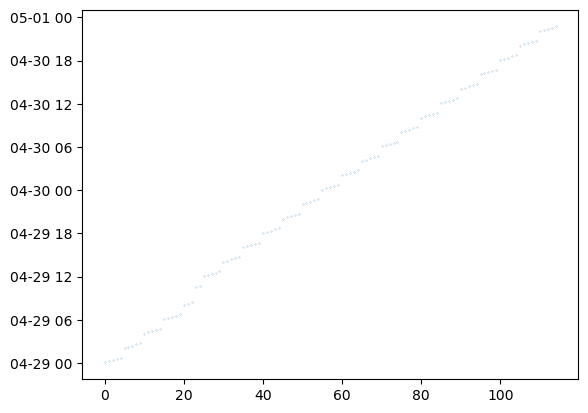

In [ ]:
clf()
plot(start_dt[1], marker=".", markersize=0.3, linestyle="none")
# plot(start_dt[2], marker=".", markersize=0.3, linestyle="none")
gcf()
# spans 2 days rather than 1, so loading all days repeats times!

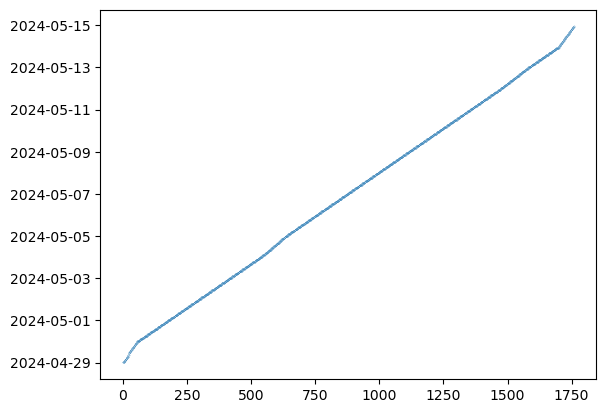

In [ ]:
# # map(x -> cat(x, dims=1), epsi)
# flt(ep) = m2n(ep) >= 0 ? ep : NaN
# nt = size(vcat(epsi...), 1)

# start_time = vcat(start_dt...)
# end_time = vcat(end_dt...)
# # uit = findfirst.(isequal.(unique(start_time)), [start_time]) # already unique
# sit = sortperm(start_time)
# clf()
# plot(start_time[sit], marker=".", markersize=0.3, linestyle="none")
# gcf()

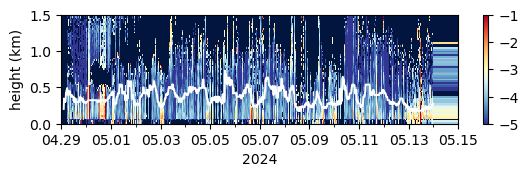

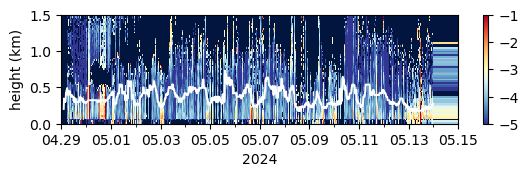

In [11]:
flt(ep) = m2n(ep) >= 0 ? ep : NaN
epsilon_all_plot = vcat(hmix_epsi...)
start_time = vcat(hmix_start_chunks...)
sit = sortperm(start_time)

leg1 = (hmix_start_time .>= DateTime(2024, 4, 29)) .& (hmix_start_time .<= DateTime(2024, 5, 15))

clf()
subplot(3,1,1)
pcolormesh(start_time[sit], rng.(1:80)/1e3, log10.(pd(flt.(epsilon_all_plot)[sit,:])), cmap=ColorMap("RdYlBu_r"), vmin=-5, vmax=-1)
plot(hmix_start_time[leg1], coalesce.(hmix_height_filt_m[leg1], NaN) ./ 1e3, color="w", linewidth=1.4)
colorbar(ticks = -1:-1:-5)
ylim([0, 1.5])
ylabel("height (km)")
xlim([Date(2024,4,29), Date(2024,5,15)])
xlabel("2024")

ax = gca()
ax.xaxis.set_major_formatter(PyPlot.matplotlib.dates.DateFormatter("%m.%d"))
mx = PyPlot.matplotlib.ticker.MultipleLocator(1)
ax.xaxis.set_minor_locator(mx)
ax.set_facecolor("xkcd:navy")

savefig("epsilon_leg1.pdf")
gcf()


In [5]:
f = files[2]
epsi = load(joinpath(epsdir, f))["epsilon"]

clf()
pcolormesh((1:size(epsi,1))*24/115, rng.(1:80)/1e3, log10.(pd(m2n.(epsi))), cmap=ColorMap("RdYlBu_r"))
colorbar()
xlabel("time, hour-ish")
ylabel("height (km)")

PyObject Text(0, 0.5, 'height (km)')

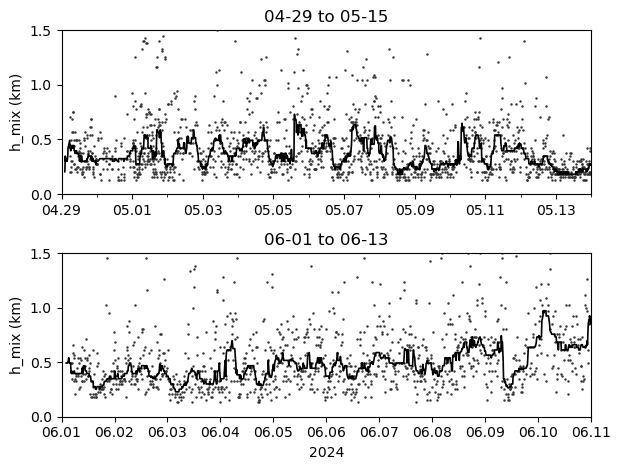

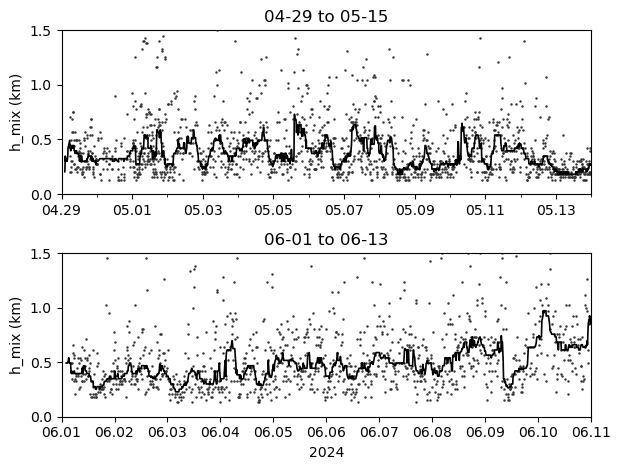

In [ ]:
# concatenate all profiles in time, compute h_mix above 100 m, and plot the result by contiguous batch
hmix_files = sort(filter(f -> startswith(f, "epsilon_2024") & endswith(f, ".jld2"), readdir(epsdir)))
hmix_epsi = Matrix{Union{Missing, Float64}}[]
hmix_start_chunks = Vector{Any}[]
hmix_end_chunks = Vector{Any}[]

for f in hmix_files
    d = load(joinpath(epsdir, f))
    push!(hmix_epsi, d["epsilon"])
    push!(hmix_start_chunks, d["start_dt"])
    push!(hmix_end_chunks, d["end_dt"])
end

epsilon_all = vcat(hmix_epsi...)
hmix_start_time = vcat(hmix_start_chunks...)
hmix_end_time = vcat(hmix_end_chunks...)
hmix_sort = sortperm(hmix_start_time)

is_valid_eps(x) = !ismissing(x) && isfinite(x) && x > 0

function hmix_first_crossing(profile; min_valid_below=1, min_height_m=100.0)
    search_start = findfirst(iz -> rng(iz) >= min_height_m, eachindex(profile))
    isnothing(search_start) && return missing

    for iz in (search_start + 1):length(profile)
        eps_i = profile[iz]
        is_valid_eps(eps_i) || continue

        below_vals = [profile[j] for j in search_start:(iz - 1) if is_valid_eps(profile[j])]
        length(below_vals) >= min_valid_below || continue

        if eps_i <= mean(below_vals) / 3
            return iz
        end
    end

    return missing
end

function moving_median_missing(x; half_window=12)
    y = Vector{Union{Missing, Float64}}(missing, length(x))
    for i in eachindex(x)
        i1 = max(firstindex(x), i - half_window)
        i2 = min(lastindex(x), i + half_window)
        vals = collect(skipmissing(x[i1:i2]))
        isempty(vals) && continue
        y[i] = median(vals)
    end
    y
end

hmix_index = [hmix_first_crossing(view(epsilon_all, it, :); min_height_m=100.0) for it in axes(epsilon_all, 1)]
hmix_height_m = Union{Missing, Float64}[ismissing(iz) ? missing : rng(iz) for iz in hmix_index]

hmix_index = hmix_index[hmix_sort]
hmix_height_m = hmix_height_m[hmix_sort]
hmix_start_time = hmix_start_time[hmix_sort]
hmix_end_time = hmix_end_time[hmix_sort]

hmix_windows = [
    (DateTime(2024, 4, 29), DateTime(2024, 5, 14), "04-29 to 05-15"),
    (DateTime(2024, 6, 1), DateTime(2024, 6, 11), "06-01 to 06-13"),
]

hmix_height_filt_m = Vector{Union{Missing, Float64}}(missing, length(hmix_height_m))
for (t1, t2, _) in hmix_windows
    mask = (hmix_start_time .>= t1) .& (hmix_start_time .<= t2)
    hmix_height_filt_m[mask] = moving_median_missing(hmix_height_m[mask]; half_window=12)
end

clf()
for (ipanel, (t1, t2, label)) in enumerate(hmix_windows)
    subplot(2, 1, ipanel)
    mask = (hmix_start_time .>= t1) .& (hmix_start_time .<= t2)
    plot(hmix_start_time[mask], coalesce.(hmix_height_m[mask], NaN) ./ 1e3, linestyle="none", marker=".", markersize=1.5, color="0.2")
    plot(hmix_start_time[mask], coalesce.(hmix_height_filt_m[mask], NaN) ./ 1e3, color="k", linewidth=1.2)
    ylabel("ABL mixing layer height (km)")
    xlim([t1, t2])
    ylim([0, 1.5])
    title(label)

    ax = gca()
    ax.xaxis.set_major_formatter(PyPlot.matplotlib.dates.DateFormatter("%m.%d"))
    mx = PyPlot.matplotlib.ticker.MultipleLocator(1)
    ax.xaxis.set_minor_locator(mx)
end

xlabel("2024")
tight_layout()
gcf()